# Сравнение InsightFace, DeepFace и facenet-pytorch

Версия с подробными комментариями непосредственно внутри кода.

В каждой кодовой ячейке пояснены:

- импорты и зависимости;
- параметры моделей;
- работа функций;
- условия и циклы;
- обработка ошибок;
- расчёт эмбеддингов и метрик;
- визуализация и сохранение результатов.

> После первой ячейки установки обязательно перезапустите ядро Jupyter.


> Версия рассчитана на Python 3.13 и не требует отдельного окружения.


In [1]:
# Установка в текущее окружение Anaconda без Python 3.12
# и без создания отдельного окружения.

import sys
import subprocess

print("Python:", sys.version)
print("Ядро:", sys.executable)

PYTHON = sys.executable

def pip_install(*packages, extra_args=None):
    """Устанавливает пакеты именно в текущее ядро Jupyter."""
    command = [PYTHON, "-m", "pip", "install"]
    if extra_args:
        command.extend(extra_args)
    command.extend(packages)
    print("\n>", " ".join(command))
    subprocess.check_call(command)

# Обновляем pip, чтобы он выбирал готовые wheel-файлы.
pip_install("pip", "setuptools", "wheel", extra_args=["--upgrade"])

# Очищаем старый кэш с неудачной попыткой сборки NumPy 1.26.4.
subprocess.run([PYTHON, "-m", "pip", "cache", "purge"], check=False)

# Для Python 3.13 используем современный NumPy 2.x.
# Сборку из исходников запрещаем.
pip_install(
    "numpy>=2.1,<2.6",
    extra_args=["--upgrade", "--only-binary=:all:"],
)

# Устанавливаем научные библиотеки.
pip_install(
    "pandas>=2.2",
    "scipy>=1.14",
    "scikit-learn>=1.6",
    "scikit-image>=0.25",
    "matplotlib>=3.9",
    "pillow>=11",
    "opencv-python>=4.10",
    extra_args=["--upgrade"],
)

# TensorFlow 2.21 имеет готовую сборку для Python 3.13.
pip_install(
    "tensorflow==2.21.0",
    "tf-keras",
    "deepface==0.0.100",
    extra_args=["--upgrade", "--only-binary=:all:"],
)

# InsightFace 1.0.1 больше не собирает face3d по умолчанию.
pip_install(
    "insightface>=1.0.1",
    "onnxruntime>=1.20",
    extra_args=["--upgrade"],
)

# Ставим современный PyTorch.
pip_install(
    "torch",
    "torchvision",
    extra_args=["--upgrade", "--only-binary=:all:"],
)

# У facenet-pytorch устаревшие ограничения numpy<2 и torch<2.3.
# --no-deps не даёт pip откатить NumPy до 1.26.4.
pip_install(
    "facenet-pytorch==2.6.0",
    extra_args=["--no-deps", "--upgrade"],
)

print("\nПроверка зависимостей:")
subprocess.run([PYTHON, "-m", "pip", "check"], check=False)

print("\nГотово. Перезапустите ядро: Kernel -> Restart Kernel.")


Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Ядро: C:\ProgramData\anaconda3\python.exe

> C:\ProgramData\anaconda3\python.exe -m pip install --upgrade pip setuptools wheel

> C:\ProgramData\anaconda3\python.exe -m pip install --upgrade --only-binary=:all: numpy>=2.1,<2.6


CalledProcessError: Command '['C:\\ProgramData\\anaconda3\\python.exe', '-m', 'pip', 'install', '--upgrade', '--only-binary=:all:', 'numpy>=2.1,<2.6']' returned non-zero exit status 1.

In [2]:
# Исправление смешанной установки DeepFace.
#
# Ошибка
# AttributeError: module 'deepface.modules.modeling'
# has no attribute 'build_model'
# означает, что Python загрузил файлы DeepFace от разных версий.
# В актуальной версии DeepFace функция modeling.build_model существует.

import sys
import site
import shutil
import subprocess
from pathlib import Path

PYTHON = sys.executable

print("Python:", sys.version)
print("Текущее ядро:", PYTHON)


def run_command(command):
    """Запускает команду и останавливает ячейку при ошибке."""
    print("\n>", " ".join(map(str, command)))
    subprocess.check_call(command)


# Удаляем зарегистрированные через pip версии DeepFace.
# Повторный uninstall безопасен: если пакета уже нет,
# pip просто сообщит об этом.
subprocess.run(
    [
        PYTHON,
        "-m",
        "pip",
        "uninstall",
        "-y",
        "deepface",
    ],
    check=False,
)

# Получаем все возможные каталоги site-packages,
# потому что остатки пакета могут лежать не только в одном месте.
site_package_dirs = set()

try:
    site_package_dirs.update(site.getsitepackages())
except Exception:
    pass

try:
    site_package_dirs.add(site.getusersitepackages())
except Exception:
    pass

# Также проверяем каталоги, которые уже присутствуют в sys.path.
for entry in sys.path:
    if entry and "site-packages" in entry.lower():
        site_package_dirs.add(entry)

# Удаляем оставшуюся папку deepface и метаданные пакета.
# Именно такие остатки часто вызывают смешивание файлов разных версий.
for directory in site_package_dirs:
    directory = Path(directory)

    if not directory.exists():
        continue

    candidates = [directory / "deepface"]
    candidates.extend(directory.glob("deepface-*.dist-info"))
    candidates.extend(directory.glob("deepface-*.egg-info"))

    for candidate in candidates:
        if candidate.exists():
            print("Удаляется остаток:", candidate)

            if candidate.is_dir():
                shutil.rmtree(
                    candidate,
                    ignore_errors=False,
                )
            else:
                candidate.unlink()

# Очищаем кэш pip, чтобы старая сборка не использовалась повторно.
subprocess.run(
    [
        PYTHON,
        "-m",
        "pip",
        "cache",
        "purge",
    ],
    check=False,
)

# Устанавливаем DeepFace заново из готового wheel-файла.
# --no-cache-dir запрещает использовать старый локальный архив.
run_command(
    [
        PYTHON,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        "--force-reinstall",
        "--no-deps",
        "deepface==0.0.100",
    ]
)

# DeepFace с TensorFlow 2.16+ использует совместимый пакет tf-keras.
run_command(
    [
        PYTHON,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "tf-keras",
    ]
)

print()
print("Чистая переустановка DeepFace завершена.")
print("ОБЯЗАТЕЛЬНО выполните Kernel -> Restart Kernel.")
print("Не запускайте следующие ячейки до перезапуска ядра.")


Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Текущее ядро: C:\ProgramData\anaconda3\python.exe

> C:\ProgramData\anaconda3\python.exe -m pip install --no-cache-dir --force-reinstall --no-deps deepface==0.0.100

> C:\ProgramData\anaconda3\python.exe -m pip install --upgrade tf-keras

Чистая переустановка DeepFace завершена.
ОБЯЗАТЕЛЬНО выполните Kernel -> Restart Kernel.
Не запускайте следующие ячейки до перезапуска ядра.


## Проверка DeepFace после перезапуска ядра

Эту ячейку запускайте только после `Kernel → Restart Kernel`.


In [3]:
# Проверяем, что загружена единая и корректная версия DeepFace.
import deepface
from deepface import DeepFace
from deepface.modules import modeling

print("DeepFace version:", deepface.__version__)
print("DeepFace path:", deepface.__file__)
print("modeling path:", modeling.__file__)
print(
    "modeling.build_model существует:",
    hasattr(modeling, "build_model"),
)

# Если здесь False, значит Jupyter всё ещё использует старое ядро
# или в sys.path присутствует другая копия пакета.
if not hasattr(modeling, "build_model"):
    raise RuntimeError(
        "Загружена неправильная копия DeepFace. "
        "Убедитесь, что ядро было перезапущено."
    )

# Пробуем создать модель заранее.
# При первом запуске веса Facenet512 могут скачиваться.
deepface_facenet512_model = DeepFace.build_model(
    model_name="Facenet512",
)

print("Facenet512 успешно загружен.")



DeepFace version: 0.0.100
DeepFace path: C:\ProgramData\anaconda3\Lib\site-packages\deepface\__init__.py
modeling path: C:\ProgramData\anaconda3\Lib\site-packages\deepface\modules\modeling.py
modeling.build_model существует: True
26-07-18 15:31:02 - 🔗 facenet512_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5 to C:\Users\Алексей\.deepface\weights\facenet512_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: C:\Users\Алексей\.deepface\weights\facenet512_weights.h5
100%|█████████████████████████████████████████████████████████████████████████████| 95.0M/95.0M [01:02<00:00, 1.51MB/s]


Facenet512 успешно загружен.


In [4]:
# Path используется для удобной и безопасной работы с путями Windows.
from pathlib import Path

# Типы делают функции понятнее и помогают видеть,
# какие значения они принимают и возвращают.
from typing import Optional, Dict, List, Tuple

# time нужен для измерения времени выполнения моделей.
import time

# warnings используется для отключения лишних предупреждений в выводе.
import warnings

# OpenCV используется для чтения и масштабирования изображений.
import cv2

# NumPy используется для работы с эмбеддингами как с числовыми векторами.
import numpy as np

# Pandas используется для формирования итоговой таблицы результатов.
import pandas as pd

# Matplotlib используется для вывода изображений и построения графиков.
import matplotlib.pyplot as plt

# PIL нужен для подготовки изображений для facenet-pytorch.
from PIL import Image

# Отключаем предупреждения, которые не влияют на выполнение эксперимента.
warnings.filterwarnings("ignore")

# Указываем Jupyter отображать графики прямо под ячейками.
%matplotlib inline

# Проверяем фактически загруженную версию protobuf.
# После исправления конфликта здесь ожидается 6.31.1.
import google.protobuf
print("protobuf:", google.protobuf.__version__)

# Импортируем TensorFlow и выводим его версию.
import tensorflow as tf
print("tensorflow:", tf.__version__)

# Импортируем PyTorch.
import torch
print("torch:", torch.__version__)

# Проверяем, доступен ли GPU с поддержкой CUDA.
print("CUDA available:", torch.cuda.is_available())

# Если CUDA доступна, используем GPU.
# В противном случае модели будут работать на CPU.
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


protobuf: 7.35.1
tensorflow: 2.21.0
torch: 2.7.1+cu128
CUDA available: True
Device: cuda


In [5]:
# Главная папка подготовленного датасета.
# При переносе проекта на другой компьютер достаточно изменить этот путь.
PROCESSED_DIR = Path(
    r"D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new"
)

# Папка с обрезанными изображениями лиц.
CROPPED_DIR = PROCESSED_DIR / "cropped_faces"

# Папка с уже выровненными изображениями лиц.
ALIGNED_DIR = PROCESSED_DIR / "aligned_faces_all"

# Возможные CSV-файлы с идентификаторами людей.
# Ноутбук выберет первый существующий файл,
# содержащий столбцы image_id и person_id.
CSV_CANDIDATES = [
    PROCESSED_DIR / "test_with_identity.csv",
    PROCESSED_DIR / "test.csv",
    PROCESSED_DIR / "dataset_info.csv",
]

# Поддерживаемые расширения изображений.
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}


def list_images(directory: Path) -> List[Path]:
    """
    Возвращает все изображения из указанной папки
    и её вложенных каталогов.
    """

    # Если папка отсутствует, возвращаем пустой список,
    # чтобы ноутбук мог попробовать другую папку.
    if not directory.exists():
        return []

    # rglob("*") рекурсивно перебирает все файлы.
    # Оставляем только существующие файлы
    # с поддерживаемыми расширениями.
    images = [
        path
        for path in directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Сортируем пути для воспроизводимого выбора изображений.
    return sorted(images)


# Получаем изображения из обеих папок.
cropped_images = list_images(CROPPED_DIR)
aligned_images = list_images(ALIGNED_DIR)

# Выводим информацию о найденных данных.
print("PROCESSED_DIR существует:", PROCESSED_DIR.exists())
print("CROPPED_DIR существует:", CROPPED_DIR.exists())
print("ALIGNED_DIR существует:", ALIGNED_DIR.exists())
print("Изображений в cropped_faces:", len(cropped_images))
print("Изображений в aligned_faces_all:", len(aligned_images))

# Если изображения не найдены ни в одной папке,
# дальнейшее выполнение эксперимента невозможно.
if not cropped_images and not aligned_images:
    raise FileNotFoundError(
        "Не найдено изображений. Проверьте путь PROCESSED_DIR."
    )

# cropped_faces предпочтительнее,
# потому что слишком тесные aligned-кропы хуже детектируются InsightFace.
preferred_images = (
    cropped_images
    if cropped_images
    else aligned_images
)


PROCESSED_DIR существует: True
CROPPED_DIR существует: True
ALIGNED_DIR существует: True
Изображений в cropped_faces: 14062
Изображений в aligned_faces_all: 14062


In [6]:
def read_rgb(path: Path) -> np.ndarray:
    """
    Читает изображение с диска и возвращает его в формате RGB.
    """

    # OpenCV читает изображение в формате BGR.
    image_bgr = cv2.imread(str(path))

    # Если файл повреждён или путь неверный,
    # cv2.imread возвращает None.
    if image_bgr is None:
        raise ValueError(
            f"Не удалось прочитать изображение: {path}"
        )

    # Matplotlib ожидает RGB, поэтому меняем порядок каналов.
    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )

    return image_rgb


def show_images(
    paths: List[Path],
    titles: Optional[List[str]] = None,
    columns: int = 4,
    figure_width: int = 16,
) -> None:
    """
    Показывает набор изображений в виде сетки.
    """

    # Если список пуст, выводить нечего.
    if not paths:
        print("Нет изображений для показа.")
        return

    # Вычисляем число строк с округлением вверх.
    rows = int(
        np.ceil(len(paths) / columns)
    )

    # Создаём сетку областей matplotlib.
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(figure_width, 4 * rows),
    )

    # Преобразуем axes в одномерный массив,
    # чтобы одинаково обрабатывать одну и несколько строк.
    axes = np.atleast_1d(axes).ravel()

    # Перебираем изображения вместе с соответствующими областями.
    for index, (axis, path) in enumerate(
        zip(axes, paths)
    ):
        try:
            # Читаем изображение и показываем его.
            axis.imshow(read_rgb(path))

            # Если подписи переданы, используем их.
            # Иначе показываем имя файла.
            title = (
                titles[index]
                if titles is not None
                else path.name
            )

            axis.set_title(title)

        except Exception as error:
            # Если один файл повреждён,
            # выводим ошибку именно в его области,
            # но не останавливаем весь ноутбук.
            axis.text(
                0.5,
                0.5,
                str(error),
                ha="center",
                va="center",
                wrap=True,
            )

        # Для изображений координатные оси не нужны.
        axis.axis("off")

    # Если сетка содержит лишние ячейки,
    # скрываем их.
    for axis in axes[len(paths):]:
        axis.axis("off")

    # Уменьшаем пересечения подписей.
    plt.tight_layout()

    # Показываем рисунок.
    plt.show()


def normalize(vector: np.ndarray) -> np.ndarray:
    """
    Выполняет L2-нормализацию эмбеддинга.
    """

    # Преобразуем данные в одномерный float32-вектор.
    vector = np.asarray(
        vector,
        dtype=np.float32,
    ).reshape(-1)

    # Вычисляем евклидову длину вектора.
    norm = np.linalg.norm(vector)

    # Нулевой вектор нельзя нормализовать.
    if norm < 1e-12:
        raise ValueError(
            "Получен нулевой эмбеддинг."
        )

    # После деления длина вектора становится равной 1.
    return vector / norm


def metrics(
    embedding_1: np.ndarray,
    embedding_2: np.ndarray,
) -> Dict[str, float]:
    """
    Сравнивает два эмбеддинга лица.
    """

    # Нормализуем оба вектора,
    # чтобы сравнение разных моделей было корректным.
    first = normalize(embedding_1)
    second = normalize(embedding_2)

    # Для нормализованных векторов
    # скалярное произведение равно косинусному сходству.
    cosine_similarity = float(
        np.dot(first, second)
    )

    # Косинусное расстояние является дополнением сходства до 1.
    cosine_distance = 1.0 - cosine_similarity

    # Евклидово расстояние измеряет длину разности векторов.
    euclidean_distance = float(
        np.linalg.norm(first - second)
    )

    return {
        "cosine_similarity": cosine_similarity,
        "cosine_distance": cosine_distance,
        "euclidean_distance": euclidean_distance,
    }


def readable(
    paths: List[Path],
    count: int,
) -> List[Path]:
    """
    Возвращает первые count изображений,
    которые удалось корректно прочитать.
    """

    result = []

    # Перебираем изображения по порядку.
    for path in paths:
        try:
            # Проверяем, что изображение действительно читается.
            image = read_rgb(path)

            # Добавляем только непустые изображения.
            if image.size > 0:
                result.append(path)

        except Exception:
            # Повреждённый файл пропускаем.
            continue

        # Останавливаемся, когда набрано нужное количество.
        if len(result) >= count:
            break

    return result


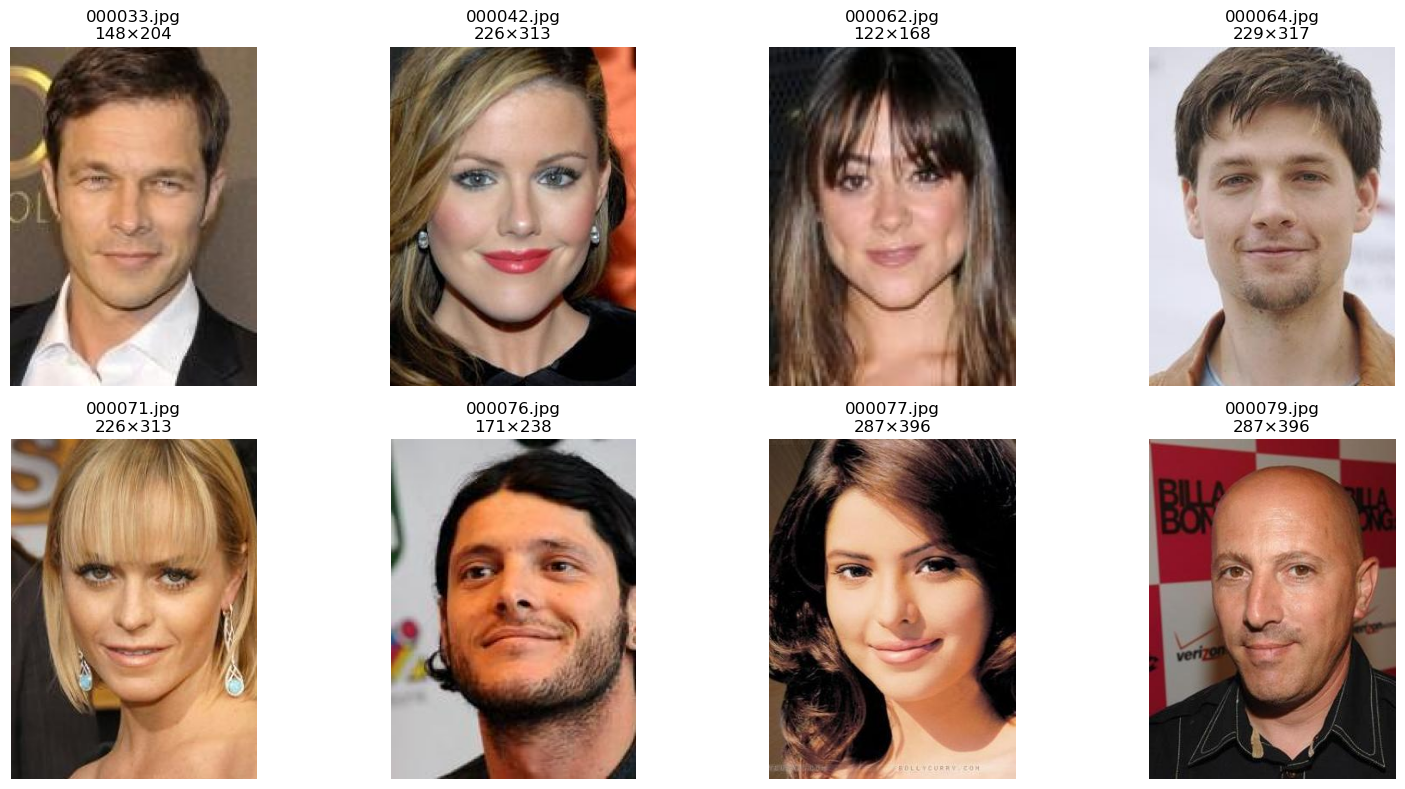

In [7]:
# Выбираем восемь первых корректно читаемых изображений.
preview = readable(
    preferred_images,
    count=8,
)

# Формируем подписи с именем файла и его разрешением.
preview_titles = []

for path in preview:
    # Читаем изображение, чтобы узнать высоту и ширину.
    image = read_rgb(path)

    # shape имеет формат: высота, ширина, число каналов.
    height, width = image.shape[:2]

    preview_titles.append(
        f"{path.name}\n{width}×{height}"
    )

# Показываем примеры из датасета.
show_images(
    preview,
    titles=preview_titles,
    columns=4,
)


Пары выбраны из: D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\test_with_identity.csv
person_id одинаковой пары: 6746
person_id другого человека: 6346


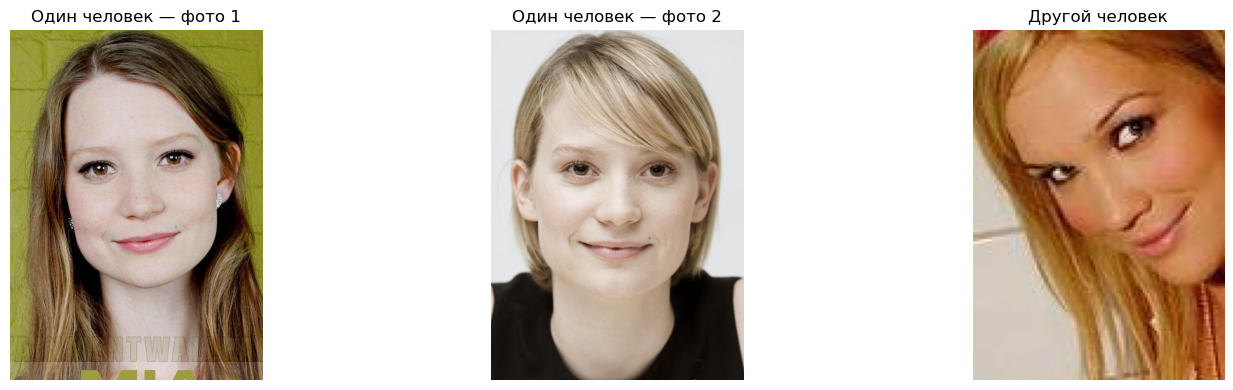

In [8]:
def resolve_image_path(
    image_id,
) -> Optional[Path]:
    """
    Ищет файл изображения по идентификатору из CSV.
    """

    # Преобразуем идентификатор в строку,
    # потому что в CSV он может быть числом.
    name = str(image_id)

    # Сначала пробуем имя в исходном виде.
    candidates = [
        CROPPED_DIR / name,
        ALIGNED_DIR / name,
    ]

    # Если расширение отсутствует,
    # добавляем наиболее распространённые варианты.
    if Path(name).suffix == "":
        for extension in [
            ".jpg",
            ".jpeg",
            ".png",
        ]:
            candidates.extend([
                CROPPED_DIR / f"{name}{extension}",
                ALIGNED_DIR / f"{name}{extension}",
            ])

    # Возвращаем первый существующий файл.
    for candidate in candidates:
        if candidate.exists():
            return candidate

    # None означает, что файл не найден.
    return None


def choose_pairs():
    """
    Выбирает:
    - две фотографии одного человека;
    - одну фотографию другого человека.
    """

    # Перебираем возможные CSV-файлы.
    for csv_path in CSV_CANDIDATES:

        # Несуществующий файл пропускаем.
        if not csv_path.exists():
            continue

        try:
            # Загружаем таблицу.
            dataframe = pd.read_csv(csv_path)

        except Exception:
            # Если CSV повреждён или имеет неподдерживаемый формат,
            # пробуем следующий файл.
            continue

        # Для автоматического выбора пар
        # необходимы два обязательных столбца.
        required_columns = {
            "image_id",
            "person_id",
        }

        if not required_columns.issubset(
            dataframe.columns
        ):
            continue

        # Создаём копию, чтобы не изменять исходную таблицу.
        dataframe = dataframe.copy()

        # Для каждого image_id ищем реальный файл.
        dataframe["image_path"] = (
            dataframe["image_id"]
            .apply(resolve_image_path)
        )

        # Удаляем строки, для которых изображение не найдено.
        dataframe = dataframe[
            dataframe["image_path"].notna()
        ]

        if dataframe.empty:
            continue

        # Считаем количество изображений каждого человека.
        person_counts = (
            dataframe
            .groupby("person_id")
            .size()
            .sort_values(ascending=False)
        )

        # Для положительной пары нужно минимум два изображения.
        eligible_people = person_counts[
            person_counts >= 2
        ]

        if eligible_people.empty:
            continue

        # Выбираем человека с наибольшим числом изображений.
        same_person_id = eligible_people.index[0]

        # Берём две фотографии выбранного человека.
        same_person_rows = dataframe[
            dataframe["person_id"] == same_person_id
        ].head(2)

        # Формируем таблицу всех остальных людей.
        different_people_rows = dataframe[
            dataframe["person_id"] != same_person_id
        ]

        # Проверяем, что обе группы действительно содержат данные.
        if (
            len(same_person_rows) < 2
            or different_people_rows.empty
        ):
            continue

        # Извлекаем пути к изображениям.
        same_image_1 = Path(
            same_person_rows.iloc[0]["image_path"]
        )

        same_image_2 = Path(
            same_person_rows.iloc[1]["image_path"]
        )

        different_image = Path(
            different_people_rows.iloc[0]["image_path"]
        )

        return {
            "same_1": same_image_1,
            "same_2": same_image_2,
            "different": different_image,
            "source": csv_path,
            "same_person_id": same_person_id,
            "different_person_id": (
                different_people_rows.iloc[0]["person_id"]
            ),
        }

    # Если подходящий CSV не найден,
    # возвращаем None и используем резервный вариант.
    return None


# Пытаемся выбрать размеченные пары по CSV.
pair_info = choose_pairs()

if pair_info is None:
    # Резервно берём первые три читаемых изображения.
    fallback = readable(
        preferred_images,
        count=3,
    )

    if len(fallback) < 3:
        raise RuntimeError(
            "Для сравнения требуется минимум три изображения."
        )

    pair_info = {
        "same_1": fallback[0],
        "same_2": fallback[1],
        "different": fallback[2],
        "source": None,
        "same_person_id": "неизвестно",
        "different_person_id": "неизвестно",
    }

    print(
        "CSV с person_id не найден. "
        "Используются первые три изображения."
    )

else:
    print("Пары выбраны из:", pair_info["source"])
    print(
        "person_id одинаковой пары:",
        pair_info["same_person_id"],
    )
    print(
        "person_id другого человека:",
        pair_info["different_person_id"],
    )

# Сохраняем пути в отдельные переменные.
SAME_IMAGE_1 = pair_info["same_1"]
SAME_IMAGE_2 = pair_info["same_2"]
DIFFERENT_IMAGE = pair_info["different"]

# Показываем выбранные изображения до запуска моделей.
show_images(
    [
        SAME_IMAGE_1,
        SAME_IMAGE_2,
        DIFFERENT_IMAGE,
    ],
    titles=[
        "Один человек — фото 1",
        "Один человек — фото 2",
        "Другой человек",
    ],
    columns=3,
)


In [9]:
# Импортируем основной класс InsightFace.
from insightface.app import FaceAnalysis

# Если CUDA доступна, сначала пробуем GPU-провайдер.
# CPU оставляем резервным вариантом.
providers = (
    [
        "CUDAExecutionProvider",
        "CPUExecutionProvider",
    ]
    if torch.cuda.is_available()
    else ["CPUExecutionProvider"]
)

# Создаём объект FaceAnalysis.
# buffalo_l включает детектор, ключевые точки и модель эмбеддингов.
insight_app = FaceAnalysis(
    name="buffalo_l",
    providers=providers,
)

# Подготавливаем модель к работе.
insight_app.prepare(
    # 0 означает GPU, -1 означает CPU.
    ctx_id=(
        0
        if torch.cuda.is_available()
        else -1
    ),

    # Размер входа детектора.
    det_size=(640, 640),

    # Пониженный порог помогает находить лица
    # на небольших и тесно обрезанных изображениях.
    det_thresh=0.30,
)

print("InsightFace готов.")


def insightface_embedding(
    path: Path,
) -> Tuple[np.ndarray, Dict]:
    """
    Получает эмбеддинг лица с помощью InsightFace.
    """

    # InsightFace работает с изображением BGR,
    # поэтому читаем файл напрямую через OpenCV.
    image_bgr = cv2.imread(str(path))

    if image_bgr is None:
        raise ValueError(
            f"Не удалось прочитать изображение: {path}"
        )

    # Запускаем детектор и модель признаков.
    faces = insight_app.get(image_bgr)

    # Если лицо не найдено,
    # увеличиваем изображение и повторяем попытку.
    if not faces:
        height, width = image_bgr.shape[:2]

        # Выбираем масштаб так, чтобы большая сторона
        # стала не меньше 640 пикселей.
        scale = max(
            2.0,
            640.0 / max(height, width),
        )

        # Используем INTER_CUBIC,
        # потому что он подходит для увеличения изображений.
        enlarged = cv2.resize(
            image_bgr,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_CUBIC,
        )

        # Повторно запускаем детекцию.
        faces = insight_app.get(enlarged)

    # Если лицо всё ещё не найдено,
    # завершаем обработку только этого изображения.
    if not faces:
        raise RuntimeError(
            f"InsightFace: лицо не найдено: {path}"
        )

    # Если найдено несколько лиц,
    # выбираем лицо с наибольшей площадью рамки.
    face = max(
        faces,
        key=lambda item: (
            (item.bbox[2] - item.bbox[0])
            * (item.bbox[3] - item.bbox[1])
        ),
    )

    # normed_embedding уже имеет единичную длину.
    embedding = getattr(
        face,
        "normed_embedding",
        None,
    )

    # В некоторых версиях normed_embedding отсутствует,
    # поэтому нормализуем обычный embedding вручную.
    if embedding is None:
        embedding = normalize(face.embedding)

    # Сохраняем диагностическую информацию.
    metadata = {
        "bbox": np.asarray(
            face.bbox
        ).tolist(),
        "det_score": float(
            face.det_score
        ),
    }

    return (
        np.asarray(
            embedding,
            dtype=np.float32,
        ),
        metadata,
    )


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Алексей/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Алексей/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Алексей/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Алексей/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Алексей/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112,

In [10]:
# Импортируем единый интерфейс DeepFace.
from deepface import DeepFace

print("DeepFace импортирован.")


def deepface_embedding(
    path: Path,
) -> Tuple[np.ndarray, Dict]:
    """
    Получает эмбеддинг Facenet512 через DeepFace.
    """

    # DeepFace.represent возвращает список представлений лиц.
    representations = DeepFace.represent(
        # Путь к изображению.
        img_path=str(path),

        # Используем модель FaceNet с эмбеддингом длины 512.
        model_name="Facenet512",

        # Изображения уже обрезаны,
        # поэтому повторная детекция не нужна.
        detector_backend="skip",

        # Не завершать выполнение при проблеме детекции.
        enforce_detection=False,

        # Не выполнять повторное выравнивание.
        align=False,

        # Используем нормализацию, соответствующую FaceNet.
        normalization="Facenet2018",
    )

    # Пустой список означает,
    # что DeepFace не вернул эмбеддинг.
    if not representations:
        raise RuntimeError(
            f"DeepFace не вернул эмбеддинг: {path}"
        )

    # Для одного изображения берём первый результат.
    first_representation = representations[0]

    # Извлекаем числовой вектор эмбеддинга.
    embedding = np.asarray(
        first_representation["embedding"],
        dtype=np.float32,
    )

    # Нормализуем вектор для дальнейшего сравнения.
    embedding = normalize(embedding)

    metadata = {
        "model": "Facenet512",
        "detector_backend": "skip",
    }

    return embedding, metadata


DeepFace импортирован.


In [11]:
# Импортируем модель FaceNet и стандартную нормализацию.
from facenet_pytorch import (
    InceptionResnetV1,
    fixed_image_standardization,
)

# transforms используется для последовательной подготовки изображения.
from torchvision import transforms

# Загружаем модель с весами, обученными на VGGFace2.
# eval() переводит модель в режим инференса.
# to(DEVICE) переносит модель на CPU или GPU.
facenet_model = (
    InceptionResnetV1(
        pretrained="vggface2"
    )
    .eval()
    .to(DEVICE)
)

# Формируем последовательность преобразований.
facenet_transform = transforms.Compose([
    # FaceNet ожидает вход 160×160.
    transforms.Resize((160, 160)),

    # Преобразуем PIL-изображение в тензор.
    transforms.ToTensor(),

    # Применяем стандартную нормализацию facenet-pytorch.
    fixed_image_standardization,
])

print("facenet-pytorch готов.")


@torch.inference_mode()
def facenet_embedding(
    path: Path,
) -> Tuple[np.ndarray, Dict]:
    """
    Получает эмбеддинг лица через facenet-pytorch.
    """

    # Открываем изображение и гарантируем формат RGB.
    image = Image.open(path).convert("RGB")

    # Применяем преобразования.
    tensor = facenet_transform(image)

    # Добавляем размерность batch:
    # было [C, H, W], стало [1, C, H, W].
    tensor = tensor.unsqueeze(0)

    # Переносим данные на CPU или GPU.
    tensor = tensor.to(DEVICE)

    # Получаем эмбеддинг.
    embedding_tensor = facenet_model(tensor)[0]

    # Отсоединяем тензор от графа,
    # переносим на CPU и преобразуем в NumPy.
    embedding = (
        embedding_tensor
        .detach()
        .cpu()
        .numpy()
    )

    # Нормализуем эмбеддинг.
    embedding = normalize(embedding)

    metadata = {
        "model": "InceptionResnetV1-vggface2",
        "input_size": "160x160",
    }

    return embedding, metadata


facenet-pytorch готов.


In [12]:
# Словарь связывает название библиотеки
# с функцией получения эмбеддинга.
MODELS = {
    "InsightFace buffalo_l": insightface_embedding,
    "DeepFace Facenet512": deepface_embedding,
    "facenet-pytorch VGGFace2": facenet_embedding,
}


def safe_run(
    model_name: str,
    function,
    path: Path,
) -> Dict:
    """
    Безопасно запускает модель на одном изображении.
    """

    # Засекаем время до запуска.
    started = time.perf_counter()

    try:
        # Получаем эмбеддинг и служебные данные.
        embedding, metadata = function(path)

        # Вычисляем длительность выполнения.
        elapsed = time.perf_counter() - started

        return {
            "model": model_name,
            "path": path,
            "ok": True,
            "embedding": embedding,
            "embedding_size": int(
                np.asarray(embedding).size
            ),
            "seconds": elapsed,
            "metadata": metadata,
            "error": None,
        }

    except Exception as error:
        # Даже при ошибке сохраняем затраченное время.
        elapsed = time.perf_counter() - started

        return {
            "model": model_name,
            "path": path,
            "ok": False,
            "embedding": None,
            "embedding_size": None,
            "seconds": elapsed,
            "metadata": None,
            "error": (
                f"{type(error).__name__}: {error}"
            ),
        }


# Словарь тестовых изображений.
test_images = {
    "same_1": SAME_IMAGE_1,
    "same_2": SAME_IMAGE_2,
    "different": DIFFERENT_IMAGE,
}

# Здесь будут храниться результаты всех моделей.
results = {}

# Перебираем модели.
for model_name, function in MODELS.items():

    # Для каждой модели создаём отдельный словарь.
    results[model_name] = {}

    print("\n" + "=" * 80)
    print(model_name)

    # Запускаем модель на каждом тестовом изображении.
    for image_key, image_path in test_images.items():

        result = safe_run(
            model_name,
            function,
            image_path,
        )

        # Сохраняем результат.
        results[model_name][image_key] = result

        if result["ok"]:
            print(
                f"{image_key}: OK | "
                f"размер эмбеддинга "
                f"{result['embedding_size']} | "
                f"{result['seconds']:.3f} сек."
            )
        else:
            print(
                f"{image_key}: ОШИБКА | "
                f"{result['error']}"
            )



InsightFace buffalo_l
same_1: OK | размер эмбеддинга 512 | 2.228 сек.
same_2: OK | размер эмбеддинга 512 | 0.759 сек.
different: OK | размер эмбеддинга 512 | 0.215 сек.

DeepFace Facenet512
same_1: OK | размер эмбеддинга 512 | 0.287 сек.
same_2: OK | размер эмбеддинга 512 | 0.195 сек.
different: OK | размер эмбеддинга 512 | 0.178 сек.

facenet-pytorch VGGFace2
same_1: OK | размер эмбеддинга 512 | 0.313 сек.
same_2: OK | размер эмбеддинга 512 | 0.056 сек.
different: OK | размер эмбеддинга 512 | 0.019 сек.


In [13]:
# Список строк будущей таблицы.
rows = []

# Перебираем результаты каждой модели.
for model_name, model_results in results.items():

    # Извлекаем результаты трёх изображений.
    same_1 = model_results["same_1"]
    same_2 = model_results["same_2"]
    different = model_results["different"]

    # Создаём строку с начальными значениями.
    row = {
        "model": model_name,
        "same_pair_ok": (
            same_1["ok"]
            and same_2["ok"]
        ),
        "different_pair_ok": (
            same_1["ok"]
            and different["ok"]
        ),
        "same_cosine_similarity": np.nan,
        "same_cosine_distance": np.nan,
        "same_euclidean_distance": np.nan,
        "different_cosine_similarity": np.nan,
        "different_cosine_distance": np.nan,
        "different_euclidean_distance": np.nan,
        "total_seconds": (
            same_1["seconds"]
            + same_2["seconds"]
            + different["seconds"]
        ),
    }

    # Если обе фотографии одного человека обработаны успешно,
    # вычисляем метрики положительной пары.
    if row["same_pair_ok"]:
        same_metrics = metrics(
            same_1["embedding"],
            same_2["embedding"],
        )

        row["same_cosine_similarity"] = (
            same_metrics["cosine_similarity"]
        )
        row["same_cosine_distance"] = (
            same_metrics["cosine_distance"]
        )
        row["same_euclidean_distance"] = (
            same_metrics["euclidean_distance"]
        )

    # Если фотографии разных людей обработаны успешно,
    # вычисляем метрики отрицательной пары.
    if row["different_pair_ok"]:
        different_metrics = metrics(
            same_1["embedding"],
            different["embedding"],
        )

        row["different_cosine_similarity"] = (
            different_metrics["cosine_similarity"]
        )
        row["different_cosine_distance"] = (
            different_metrics["cosine_distance"]
        )
        row["different_euclidean_distance"] = (
            different_metrics["euclidean_distance"]
        )

    # Добавляем строку в итоговый список.
    rows.append(row)

# Преобразуем список словарей в таблицу pandas.
comparison_df = pd.DataFrame(rows)

# Показываем таблицу с округлением.
comparison_df.round(4)


,model,same_pair_ok,different_pair_ok,same_cosine_similarity,same_cosine_distance,same_euclidean_distance,different_cosine_similarity,different_cosine_distance,different_euclidean_distance,total_seconds
0,InsightFace buffalo_l,True,True,0.6648,0.3352,0.8187,0.0764,0.9236,1.3591,3.2023
1,DeepFace Facenet512,True,True,0.5259,0.4741,0.9737,0.3028,0.6972,1.1808,0.6598
2,facenet-pytorch VGGFace2,True,True,1.0000,-0.0000,0.0000,1.0000,-0.0000,0.0000,0.3882


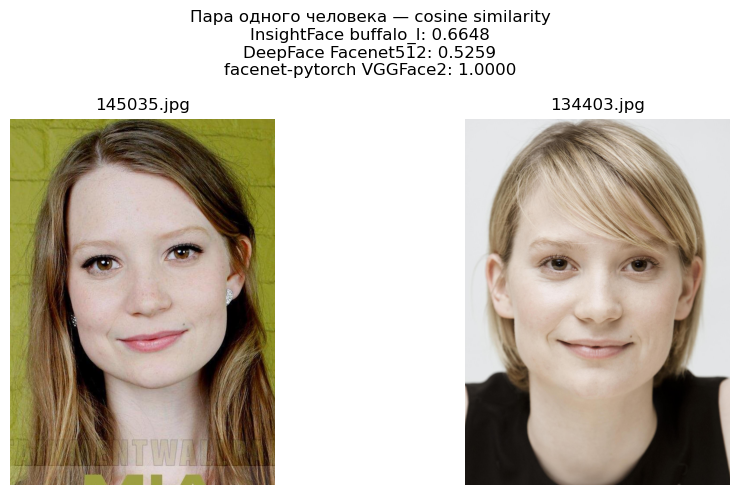

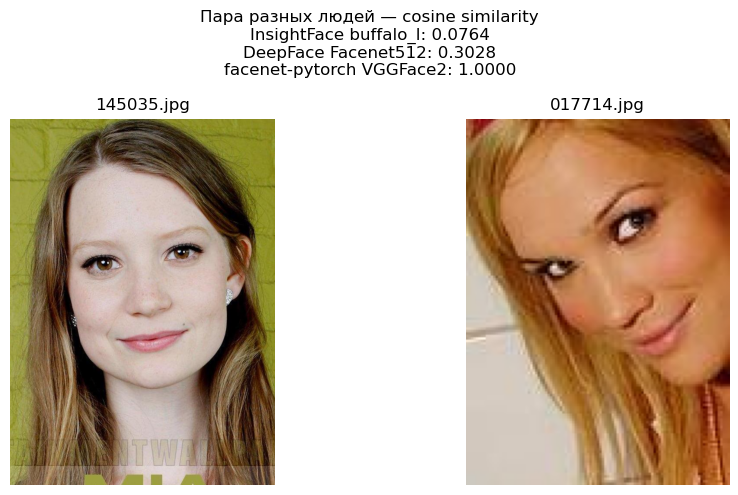

In [14]:
def format_score(value) -> str:
    """
    Форматирует число для подписи рисунка.
    """

    # Для отсутствующего значения выводим слово "ошибка".
    if value is None or pd.isna(value):
        return "ошибка"

    # Округляем значение до четырёх знаков.
    return f"{value:.4f}"


def show_pair(
    image_1: Path,
    image_2: Path,
    title: str,
    score_column: str,
) -> None:
    """
    Показывает два изображения и оценки всех моделей.
    """

    # Создаём две области для изображений.
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(10, 5),
    )

    # Показываем первое изображение.
    axes[0].imshow(
        read_rgb(image_1)
    )
    axes[0].set_title(
        image_1.name
    )
    axes[0].axis("off")

    # Показываем второе изображение.
    axes[1].imshow(
        read_rgb(image_2)
    )
    axes[1].set_title(
        image_2.name
    )
    axes[1].axis("off")

    # Формируем строки со значениями моделей.
    score_lines = []

    for _, row in comparison_df.iterrows():
        score_lines.append(
            f"{row['model']}: "
            f"{format_score(row[score_column])}"
        )

    # Добавляем общий заголовок
    # и значения косинусного сходства.
    figure.suptitle(
        title
        + "\n"
        + "\n".join(score_lines),
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()


# Показываем пару одного человека.
show_pair(
    SAME_IMAGE_1,
    SAME_IMAGE_2,
    "Пара одного человека — cosine similarity",
    "same_cosine_similarity",
)

# Показываем пару разных людей.
show_pair(
    SAME_IMAGE_1,
    DIFFERENT_IMAGE,
    "Пара разных людей — cosine similarity",
    "different_cosine_similarity",
)


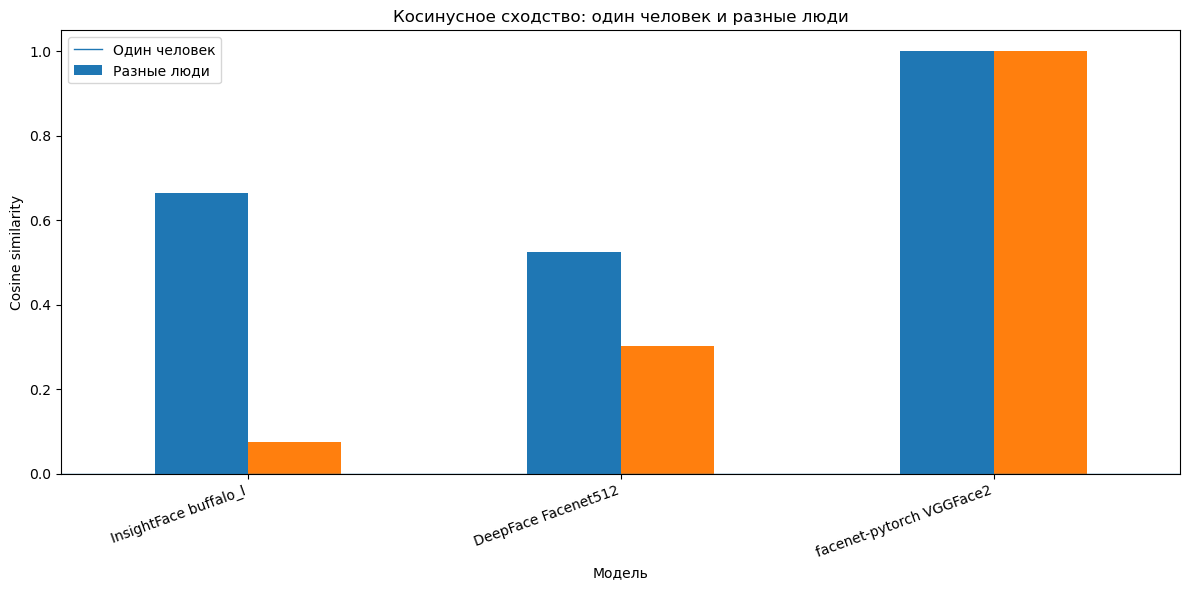

In [15]:
# Выбираем только столбцы,
# необходимые для сравнительного графика.
plot_df = comparison_df[
    [
        "model",
        "same_cosine_similarity",
        "different_cosine_similarity",
    ]
].set_index("model")

# Строим столбчатую диаграмму.
axis = plot_df.plot(
    kind="bar",
    figsize=(12, 6),
)

# Добавляем название графика.
axis.set_title(
    "Косинусное сходство: "
    "один человек и разные люди"
)

# Подписываем оси.
axis.set_ylabel(
    "Cosine similarity"
)
axis.set_xlabel(
    "Модель"
)

# Проводим нулевую горизонтальную линию.
axis.axhline(
    0,
    linewidth=1,
)

# Добавляем понятную легенду.
axis.legend([
    "Один человек",
    "Разные люди",
])

# Наклоняем названия моделей,
# чтобы они не перекрывались.
plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()
plt.show()


In [16]:
# Список всех неуспешных запусков.
errors = []

# Перебираем результаты моделей.
for model_name, model_results in results.items():

    # Перебираем изображения внутри текущей модели.
    for image_key, result in model_results.items():

        # Добавляем только ошибки.
        if not result["ok"]:
            errors.append({
                "model": model_name,
                "image": image_key,
                "path": str(result["path"]),
                "error": result["error"],
            })

# Если ошибки есть, показываем их таблицей.
if errors:
    error_df = pd.DataFrame(errors)
    display(error_df)

else:
    print(
        "Все модели успешно обработали "
        "все выбранные изображения."
    )

# Создаём папку для результатов.
RESULTS_DIR = (
    PROCESSED_DIR
    / "benchmark_results"
)

# parents=True создаёт недостающие родительские папки.
# exist_ok=True не вызывает ошибку,
# если папка уже существует.
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Формируем путь к итоговому CSV-файлу.
comparison_path = (
    RESULTS_DIR
    / "libraries_comparison.csv"
)

# Сохраняем таблицу.
# utf-8-sig обеспечивает корректное открытие русского текста в Excel.
comparison_df.to_csv(
    comparison_path,
    index=False,
    encoding="utf-8-sig",
)

print(
    "Таблица сохранена:",
    comparison_path,
)


Все модели успешно обработали все выбранные изображения.
Таблица сохранена: D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\benchmark_results\libraries_comparison.csv


## Автоматические выводы по сравнению моделей

Следующая ячейка определяет лучшую и худшую модель по разделению одинаковых и разных лиц, скорости и стабильности.


In [17]:
# Создаём копию итоговой таблицы, чтобы не изменять исходные результаты.
analysis_df = comparison_df.copy()

# Разделяющий интервал показывает, насколько сильно модель
# отделяет пару одного человека от пары разных людей.
# Чем больше значение, тем лучше модель разделяет два класса.
analysis_df["separation_margin"] = (
    analysis_df["same_cosine_similarity"]
    - analysis_df["different_cosine_similarity"]
)

# Считаем количество успешно обработанных пар.
# Максимальное значение равно 2:
# одна положительная и одна отрицательная пара.
analysis_df["successful_pairs"] = (
    analysis_df["same_pair_ok"].astype(int)
    + analysis_df["different_pair_ok"].astype(int)
)

# Сюда будут добавляться итоговые текстовые выводы.
conclusions = []

# Оставляем только модели, для которых рассчитаны обе основные метрики.
valid_accuracy = analysis_df.dropna(
    subset=[
        "same_cosine_similarity",
        "different_cosine_similarity",
        "separation_margin",
    ]
)

if not valid_accuracy.empty:
    # Модель с максимальным интервалом лучше всего разделила классы.
    best_quality = valid_accuracy.loc[
        valid_accuracy["separation_margin"].idxmax()
    ]

    # Модель с минимальным интервалом хуже всего разделила классы.
    worst_quality = valid_accuracy.loc[
        valid_accuracy["separation_margin"].idxmin()
    ]

    conclusions.append(
        f"По качеству разделения лучшей оказалась модель "
        f"{best_quality['model']}. "
        f"Её разделяющий интервал равен "
        f"{best_quality['separation_margin']:.4f}. "
        f"Большой интервал означает, что сходство фотографий "
        f"одного человека заметно выше сходства фотографий разных людей."
    )

    conclusions.append(
        f"Худший результат по разделению показала модель "
        f"{worst_quality['model']}. "
        f"Её разделяющий интервал равен "
        f"{worst_quality['separation_margin']:.4f}. "
        f"Это означает, что в данном примере граница между совпадением "
        f"и несовпадением выражена слабее."
    )

# Определяем самую быструю и самую медленную модель.
valid_speed = analysis_df.dropna(subset=["total_seconds"])

if not valid_speed.empty:
    fastest = valid_speed.loc[
        valid_speed["total_seconds"].idxmin()
    ]

    slowest = valid_speed.loc[
        valid_speed["total_seconds"].idxmax()
    ]

    conclusions.append(
        f"Самой быстрой в текущем запуске стала "
        f"{fastest['model']}: "
        f"{fastest['total_seconds']:.3f} сек. "
        f"Она лучше подходит для сценариев, где важна скорость обработки."
    )

    conclusions.append(
        f"Самой медленной в текущем запуске стала "
        f"{slowest['model']}: "
        f"{slowest['total_seconds']:.3f} сек. "
        f"На результат могут влиять загрузка весов, прогрев модели, "
        f"детекция лица и используемый вычислительный фреймворк."
    )

# Определяем устойчивость моделей по количеству успешных сравнений.
best_stability = analysis_df.loc[
    analysis_df["successful_pairs"].idxmax()
]

worst_stability = analysis_df.loc[
    analysis_df["successful_pairs"].idxmin()
]

conclusions.append(
    f"Наиболее стабильной в данном тесте стала "
    f"{best_stability['model']}: "
    f"успешно обработано "
    f"{int(best_stability['successful_pairs'])} из 2 пар."
)

if (
    worst_stability["successful_pairs"]
    < best_stability["successful_pairs"]
):
    conclusions.append(
        f"Наименее стабильной стала "
        f"{worst_stability['model']}: "
        f"успешно обработано "
        f"{int(worst_stability['successful_pairs'])} из 2 пар. "
        f"Причиной могут быть ошибки детекции, тесная обрезка лица "
        f"или особенности подготовки изображения."
    )

# Добавляем качественные выводы о библиотеках.
conclusions.append(
    "InsightFace обычно лучше подходит для практической системы "
    "распознавания лиц, потому что объединяет детектор, выравнивание "
    "и современную модель эмбеддингов. Его сильная сторона — полный "
    "пайплайн, слабая — более сложная установка и зависимость от ONNX Runtime."
)

conclusions.append(
    "DeepFace удобнее для быстрых экспериментов, потому что предоставляет "
    "единый интерфейс к разным моделям и детекторам. Его слабая сторона — "
    "дополнительные накладные расходы и более сложные зависимости TensorFlow."
)

conclusions.append(
    "facenet-pytorch удобен для исследовательского кода на PyTorch "
    "и хорошо работает с уже обрезанными и выровненными лицами. "
    "Его слабая сторона в данном ноутбуке — отсутствие собственного "
    "полного этапа детекции при использовании только InceptionResnetV1."
)

# Формируем итоговую рекомендацию по фактическим результатам.
if not valid_accuracy.empty:
    conclusions.append(
        f"Итоговая рекомендация по этому запуску: "
        f"{best_quality['model']}, поскольку она показала "
        f"лучший разделяющий интервал."
    )

# Обязательно поясняем ограничение эксперимента.
conclusions.append(
    "Этот вывод является предварительным, потому что построен только "
    "на трёх изображениях. Для полноценного сравнения нужны сотни "
    "или тысячи пар, ROC-кривая, AUC, EER, FAR, FRR и отдельный порог "
    "для каждой модели."
)

# Выводим все выводы в удобном нумерованном виде.
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 80)

for number, text in enumerate(conclusions, start=1):
    print(f"{number}. {text}\n")


ИТОГОВЫЕ ВЫВОДЫ
1. По качеству разделения лучшей оказалась модель InsightFace buffalo_l. Её разделяющий интервал равен 0.5885. Большой интервал означает, что сходство фотографий одного человека заметно выше сходства фотографий разных людей.

2. Худший результат по разделению показала модель facenet-pytorch VGGFace2. Её разделяющий интервал равен 0.0000. Это означает, что в данном примере граница между совпадением и несовпадением выражена слабее.

3. Самой быстрой в текущем запуске стала facenet-pytorch VGGFace2: 0.388 сек. Она лучше подходит для сценариев, где важна скорость обработки.

4. Самой медленной в текущем запуске стала InsightFace buffalo_l: 3.202 сек. На результат могут влиять загрузка весов, прогрев модели, детекция лица и используемый вычислительный фреймворк.

5. Наиболее стабильной в данном тесте стала InsightFace buffalo_l: успешно обработано 2 из 2 пар.

6. InsightFace обычно лучше подходит для практической системы распознавания лиц, потому что объединяет детектор, выр

## Итоговое ранжирование


In [18]:
# Формируем компактную таблицу для сравнения моделей.
ranking_df = analysis_df[
    [
        "model",
        "same_cosine_similarity",
        "different_cosine_similarity",
        "separation_margin",
        "total_seconds",
        "successful_pairs",
    ]
].copy()

# Сортируем модели от лучшего разделения к худшему.
ranking_df = ranking_df.sort_values(
    by="separation_margin",
    ascending=False,
)

# Добавляем номер места.
ranking_df.insert(
    0,
    "Место",
    range(1, len(ranking_df) + 1),
)

# Переименовываем столбцы для более понятного вывода.
ranking_df = ranking_df.rename(
    columns={
        "model": "Модель",
        "same_cosine_similarity": "Сходство одного человека",
        "different_cosine_similarity": "Сходство разных людей",
        "separation_margin": "Разделяющий интервал",
        "total_seconds": "Время, сек.",
        "successful_pairs": "Успешных пар",
    }
)

ranking_df.round(4)


,Место,Модель,Сходство одного человека,Сходство разных людей,Разделяющий интервал,"Время, сек.",Успешных пар
0,1,InsightFace buffalo_l,0.6648,0.0764,0.5885,3.2023,2
1,2,DeepFace Facenet512,0.5259,0.3028,0.2231,0.6598,2
2,3,facenet-pytorch VGGFace2,1.0000,1.0000,0.0000,0.3882,2
